conexión con sentinel-2 y datos


In [1]:
%pip install python-dotenv

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install sentinelhub

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
     ---------------------------------------- 0.0/44.9 kB ? eta -:--:--
     ---------------------------------------- 44.9/44.9 kB 2.3 MB/s eta 0:00:00
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
   ---------------------------------------- 0.0/240.4 kB ? eta -:--:--
   ------------------ --------------------- 112.6/240.4 kB 3.3 MB/s eta 0:00:01
   ---------------------------------------  235.5/240.4 kB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 240.4/240.4 kB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/165.6 kB ? eta -:--:--
   


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install rasterio

  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/25.7 MB 660.6 kB/s eta 0:00:39
   ---------------------------------------- 0.2/25.7 MB 1.5 MB/s eta 0:00:17
   ---------------------------------------- 0.3/25.7 MB 2.2 MB/s eta 0:00:12
    --------------------------------------- 0.5/25.7 MB 3.2 MB/s eta 0:00:09
   - -------------------------------------- 1.1/25.7 MB 4.9 MB/s eta 0:00:06
   -- ------------------------------------- 1.6/25.7 MB 6.2 MB/s eta 0:00:04
   ---- ----------------------------------- 2.6/25.7 MB 8.7 MB/s eta 0:00:03
   ---- ----------------------------------- 2.9/25.7 MB 8.7 MB/s eta 0:00:03
   ----- ---------------------------------- 3.8/25.7 MB 10.2 MB/s eta 0:00:03
   ------- -------------------------------- 4.5/25.7 MB 11.2 MB/s eta 0:00:02
   -------- ---------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from datetime import datetime

from sentinelhub import (
    SHConfig,
    CRS,
    BBox,
    DataCollection,
    SentinelHubRequest,
    MimeType,
    bbox_to_dimensions
)

# para datos espaciales
import rasterio
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt


C:\Users\belen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
from dotenv import load_dotenv
from sentinelhub import SHConfig

load_dotenv()

config = SHConfig()

config.sh_client_id = os.getenv("SH_CLIENT_ID")
config.sh_client_secret = os.getenv("SH_CLIENT_SECRET")

print("Client ID configurado:", bool(config.sh_client_id))
print("Client Secret configurado:", bool(config.sh_client_secret))

Client ID configurado: True
Client Secret configurado: True


#### coordenadas de los lagos

In [4]:
# coordenadas de los lagos que están en el lab 
lagos = {
    'Atitlán': {
        'west': -91.326256 ,
        'east': -91.07151 ,
        'south': 14.5948 ,
        'north': 14.750979
    },

    'Amatitlán': {
        'west': -90.638065 ,
        'east': -90.512924 ,
        'south': 14.412347 ,
        'north': 14.493799
    }
}

# fechas dadas en el lab
fechas_atitlan = [ '2025-01-18', '2025-04-13', '2025-05-13', '2025-07-17', '2025-11-21', '2025-12-29', '2026-02-12', '2026-03-24', '2026-04-13', '2026-04-28', '2026-07-22' ]

fechas_amatitlan = [ '2025-01-28', '2025-04-15', '2025-04-28', '2025-11-24', '2026-01-08', '2026-02-02', '2026-02-07', '2026-03-29', '2026-04-13', '2026-04-28', '2026-06-19' ]

fechas = { 'Atitlán': fechas_atitlan, 'Amatitlán': fechas_amatitlan }

print("Lagos definidos:")
for lago, coords in lagos.items(): print(f"  {lago}: {coords}")
print(f"\nFechas por lago:")
for lago, fecha_list in fechas.items(): print(f"  {lago}: {len(fecha_list)} fechas")

Lagos definidos:
  Atitlán: {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979}
  Amatitlán: {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799}

Fechas por lago:
  Atitlán: 11 fechas
  Amatitlán: 11 fechas


directorio para guardar datos

In [5]:
# Crear carpeta para guardar datos descargados
data_dir = Path('datos_sentinel')
data_dir.mkdir(exist_ok=True)

# Subcarpetas para cada lago
for lago in lagos.keys():
    lago_dir = data_dir / lago
    lago_dir.mkdir(exist_ok=True)

print(f"Directorio de datos: {data_dir.absolute()}")
print(f"Subdirectorios creados para cada lago")

Directorio de datos: c:\Users\belen\Documents\Data Science\DataS_Lab4_GeoEspaciales\datos_sentinel
Subdirectorios creados para cada lago


#### ddescargar datos de Sentinel-2

aquí bandas necesarias para calcular 
NDVI: B04 (Rojo) y B08 (NIR - Near Infrared)
NDWI: B03 (Verde) y B08 (NIR)
Cianobacteria

In [23]:
def descargar_bandas_sentinelhub(bbox, fecha, lago_nombre, config=None):

    # bandas necesarias: B03 (verde), B04 (rojo), B05 (red edge), B08 (NIR), SCL
    # B05 
    request = SentinelHubRequest(
        evalscript="""
            //VERSION=3
            function setup() {
                return {
                    input: [{
                        bands: ["B03", "B04", "B05", "B08", "SCL"],
                        units: "DN"
                    }],
                    output: {
                        bands: 5,
                        sampleType: "FLOAT32"
                    }
                };
            }

            function evaluatePixel(sample) {
                return [sample.B03, sample.B04, sample.B05, sample.B08, sample.SCL];
            }
        """,

        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=(fecha, fecha),
            )
        ],

        responses=[
            SentinelHubRequest.output_response("default", MimeType.TIFF)
        ],

        bbox=bbox,
        size=bbox_to_dimensions(bbox, resolution=12),
        config=config
    )

    try:
        data = request.get_data()
        print(f"descargado: {lago_nombre} y {fecha}")
        return data[0]

    except Exception as e:
        print(f"error para: {lago_nombre} y {fecha}: {str(e)}")
        return None


print("descarga lista (con B05 para NDCI)")

descarga lista (con B05 para NDCI)


In [24]:
import time

datos_descargados = {}

for lago_nombre, coords in lagos.items():

    print("\n" + "=" * 60 )
    print(f"descargando para {lago_nombre}")
    print("=" * 60)

    bbox = BBox(
        [ coords["west"],
            coords["south"],
            coords["east"],
            coords["north"]
        ],
        crs = CRS.WGS84
    )

    datos_descargados[lago_nombre] = {}

    for i, fecha in enumerate(fechas[lago_nombre]):

        print(
            f"\n[{i+1}/{len(fechas[lago_nombre])}] "
            f"descargando {fecha} "
        )

        data = descargar_bandas_sentinelhub(
            bbox,
            fecha,
            lago_nombre,
            config
        )

        if data is not None:
            datos_descargados[lago_nombre][fecha] = data
            print(f"shape: {data.shape}")

        if i < len(fechas[lago_nombre]) - 1: time.sleep(2)


print( "\ndescarga hecha " f"total: {sum(len(v) for v in datos_descargados.values())}" )


descargando para Atitlán

[1/11] descargando 2025-01-18 
descargado: Atitlán y 2025-01-18
shape: (1458, 2275, 5)

[2/11] descargando 2025-04-13 
descargado: Atitlán y 2025-04-13
shape: (1458, 2275, 5)

[3/11] descargando 2025-05-13 
descargado: Atitlán y 2025-05-13
shape: (1458, 2275, 5)

[4/11] descargando 2025-07-17 
descargado: Atitlán y 2025-07-17
shape: (1458, 2275, 5)

[5/11] descargando 2025-11-21 
descargado: Atitlán y 2025-11-21
shape: (1458, 2275, 5)

[6/11] descargando 2025-12-29 
descargado: Atitlán y 2025-12-29
shape: (1458, 2275, 5)

[7/11] descargando 2026-02-12 
descargado: Atitlán y 2026-02-12
shape: (1458, 2275, 5)

[8/11] descargando 2026-03-24 
descargado: Atitlán y 2026-03-24
shape: (1458, 2275, 5)

[9/11] descargando 2026-04-13 
descargado: Atitlán y 2026-04-13
shape: (1458, 2275, 5)

[10/11] descargando 2026-04-28 
descargado: Atitlán y 2026-04-28
shape: (1458, 2275, 5)

[11/11] descargando 2026-07-22 
descargado: Atitlán y 2026-07-22
shape: (1458, 2275, 5)

des

In [25]:
bandas_procesadas = {}

for lago_nombre, fechas_dict in datos_descargados.items():
    print(f"\nguardando  {lago_nombre}"  )

    bandas_procesadas[lago_nombre] = {}

    for fecha, data in fechas_dict.items():

        B03 = data[:, :, 0 ]
        B04 = data[:, :, 1 ]
        B05 = data[:, :, 2 ]  
        B08 = data[:, :, 3 ]
        SCL = data[:, :, 4 ]

        bandas_procesadas[lago_nombre][fecha] = {
            "B03": B03  ,
            "B04": B04 ,
            "B05": B05 , 
            "B08": B08 ,
            "SCL": SCL
        }

        lago_dir = data_dir / lago_nombre / fecha
        lago_dir.mkdir(exist_ok = True, parents = True)

        np.save(lago_dir / "B03.npy", B03)
        np.save(lago_dir / "B04.npy", B04)
        np.save(lago_dir / "B05.npy", B05)
        np.save(lago_dir / "B08.npy", B08)
        np.save(lago_dir / "SCL.npy", SCL)

        print(f"{fecha} ")

print("\ntodas las bandas ya están guardadas")


guardando  Atitlán
2025-01-18 
2025-04-13 
2025-05-13 
2025-07-17 
2025-11-21 
2025-12-29 
2026-02-12 
2026-03-24 
2026-04-13 
2026-04-28 
2026-07-22 

guardando  Amatitlán
2025-01-28 
2025-04-15 
2025-04-28 
2025-11-24 
2026-01-08 
2026-02-02 
2026-02-07 
2026-03-29 
2026-04-13 
2026-04-28 
2026-06-19 

todas las bandas ya están guardadas


In [26]:
print("verificar las  descargas \n")

total_archivos = 0
for lago_nombre in lagos.keys():
    lago_path = data_dir / lago_nombre
    fechas_guardadas = sorted( [f.name for f in lago_path.iterdir() if f.is_dir()])

    print(f" \n{lago_nombre}:" )
    print(f"  total fechas: { len(fechas_guardadas) }" )

    # 1r fecha
    if fechas_guardadas:
        primera_fecha = fechas_guardadas[0  ]
        fecha_path = lago_path / primera_fecha
        archivos = list(fecha_path.glob('*.npy'))

        for archivo in archivos:
            arr = np.load(archivo)
            print(f" {archivo.name}: {arr.shape}")

        total_archivos += len(archivos)

print(f"\n total de los archivos guardados: {total_archivos}")

verificar las  descargas 

 
Atitlán:
  total fechas: 11
 B03.npy: (1458, 2275)
 B04.npy: (1458, 2275)
 B05.npy: (1458, 2275)
 B08.npy: (1458, 2275)
 CYANO.npy: (1458, 2275)
 NDVI.npy: (1458, 2275)
 NDWI.npy: (1458, 2275)
 SCL.npy: (1458, 2275)
 
Amatitlán:
  total fechas: 11
 B03.npy: (763, 1117)
 B04.npy: (763, 1117)
 B05.npy: (763, 1117)
 B08.npy: (763, 1117)
 CYANO.npy: (763, 1117)
 NDVI.npy: (763, 1117)
 NDWI.npy: (763, 1117)
 SCL.npy: (763, 1117)

 total de los archivos guardados: 16


## 2 datos raster listos


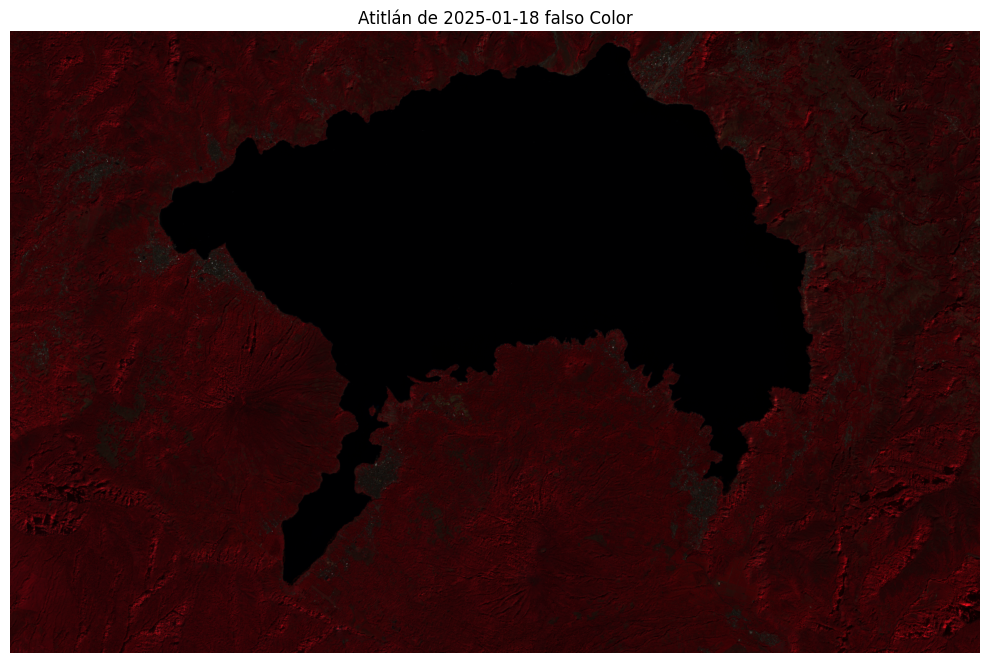

In [27]:
import matplotlib.pyplot as plt

primer_lago = 'Atitlán'
primera_fecha = fechas[primer_lago][0]

B03 = bandas_procesadas[primer_lago][ primera_fecha]['B03' ]
B04 = bandas_procesadas[primer_lago][ primera_fecha]['B04' ]
B08 =  bandas_procesadas[primer_lago][ primera_fecha]['B08' ]

# normalizar para 
B03_norm = (B03 - np.nanmin(B03)) / (np.nanmax(B03) - np.nanmin( B03) + 1e-8 )
B04_norm = (B04 - np.nanmin(B04)) / (np.nanmax(B04) - np.nanmin( B04) + 1e-8 )
B08_norm = (B08 - np.nanmin(B08)) / (np.nanmax(B08) - np.nanmin( B08) + 1e-8)

# composición color nir, rojo y verde 
rgb = np.stack([B08_norm, B04_norm, B03_norm] , axis = 2)

plt.figure(figsize = ( 10, 8) )
plt.imshow(rgb)
plt.title( f'{primer_lago} de { primera_fecha} falso Color' )
plt.axis( 'off' )
plt.tight_layout()
plt.savefig('verificacion_imagen.png', dpi = 100 , bbox_inches = 'tight' )
plt.show()


# 3 calcular índices


In [34]:
def calcular_ndvi(B04, B08):
   
    numerador = B08.astype(float ) - B04.astype(float )
    denominador = B08.astype(float ) + B04.astype(float)
    
    # no división por cero
    ndvi = np.divide(numerador , denominador , where = denominador !=  0, out = np.zeros_like( numerador))
    
    return ndvi

print("función NDVI")

función NDVI


In [35]:
def calcular_ndwi(B03, B08):
 
    numerador = B03.astype(float ) - B08.astype(float)
    denominador = B03.astype(float ) + B08.astype(float)
    
    ndwi = np.divide(numerador , denominador , where = denominador !=  0, out = np.zeros_like( numerador))
    
    return ndwi

print("función NDWI")

función NDWI


In [43]:
def calcular_cyano_ndci(B04, B05):
    
    B04_f = B04.astype(float)
    B05_f = B05.astype(float)
    
    # ndci
    numerador = B05_f - B04_f
    denominador = B05_f + B04_f
    ndci = np.divide(numerador, denominador , where=denominador != 0 , out= np.zeros_like(numerador))
    
    ndci = np.divide(
        numerador,
        denominador,
        where = denominador != 0 ,
        out = np.zeros_like(numerador)
    )
    
    # estimación de chlorophyll-a 
    chl_a = ( 826.57 * ndci**3 - 176.43 * ndci**2  + 19 * ndci + 4.071  )
    
    return chl_a

print("función de estimación de chlorophyll-a basada en NDCI lista")

función de estimación de chlorophyll-a basada en NDCI lista


In [63]:
# diccionario para guardar todos los índices
indices_calculados = {}

for lago_nombre in lagos.keys():
    print(f"\n{'---'*3}")
    print(f"calculando índices para {lago_nombre}")

    
    indices_calculados[lago_nombre] = {}
    
    for fecha in sorted(bandas_procesadas[lago_nombre].keys()):

        B03 = bandas_procesadas[lago_nombre ][fecha]['B03']
        B04 = bandas_procesadas[lago_nombre ][fecha]['B04']
        B05 = bandas_procesadas[lago_nombre ][fecha]['B05' ]  
        B08 = bandas_procesadas[lago_nombre ][fecha]['B08']
        
        ndvi = calcular_ndvi(B04, B08)
        ndwi = calcular_ndwi(B03, B08)
        cyano = calcular_cyano_ndci(B04, B05)  
        
        mascara_agua = ndwi > 0
        cyano = np.where(mascara_agua, cyano , np.nan)
        
        cyano = np.where( (cyano >= 0 ) & (cyano <= 500), cyano , np.nan)

        
        indices_calculados[lago_nombre][fecha] = {
            'NDVI': ndvi,
            'NDWI': ndwi,
            'CYANO': cyano
        }
        
        
        lago_dir = data_dir / lago_nombre / fecha

        print(f"{fecha}: " f"NDVI min = {ndvi.min():.4f} max= {ndvi.max():.4f} y " f"NDWI min= {ndwi.min():.4f} max = {ndwi.max():.4f} y " f"CYANO min= {np.nanmin(cyano):.4f} " f"max= {np.nanmax(cyano):.4f} " f"promedio= {np.nanmean(cyano):.4f}" )


---------
calculando índices para Atitlán
2025-01-18: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 498.9231 promedio= 12.6697
2025-04-13: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 283.7743 promedio= 3.4445
2025-05-13: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 338.7002 promedio= 3.9779
2025-07-17: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 476.8043 promedio= 4.5482
2025-11-21: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0003 max= 496.9719 promedio= 10.8963
2025-12-29: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0052 max= 496.5481 promedio= 5.7913
2026-02-12: NDVI min = -1.0000 max= 1.0000 y NDWI min= -1.0000 max = 1.0000 y CYANO min= 0.0059 max= 498.3353 promedio= 6.8264
2026-03-24: NDVI min = -1.0000 max= 0.9176 y NDWI min= -1.0000 max

# 3.1 y 3.2

NDVI: (B08 - B04) / (B08 + B04)  

NDWI: (B03 - B08) / (B03 + B08)  

CYANO: fai usando B03, B04 y B08

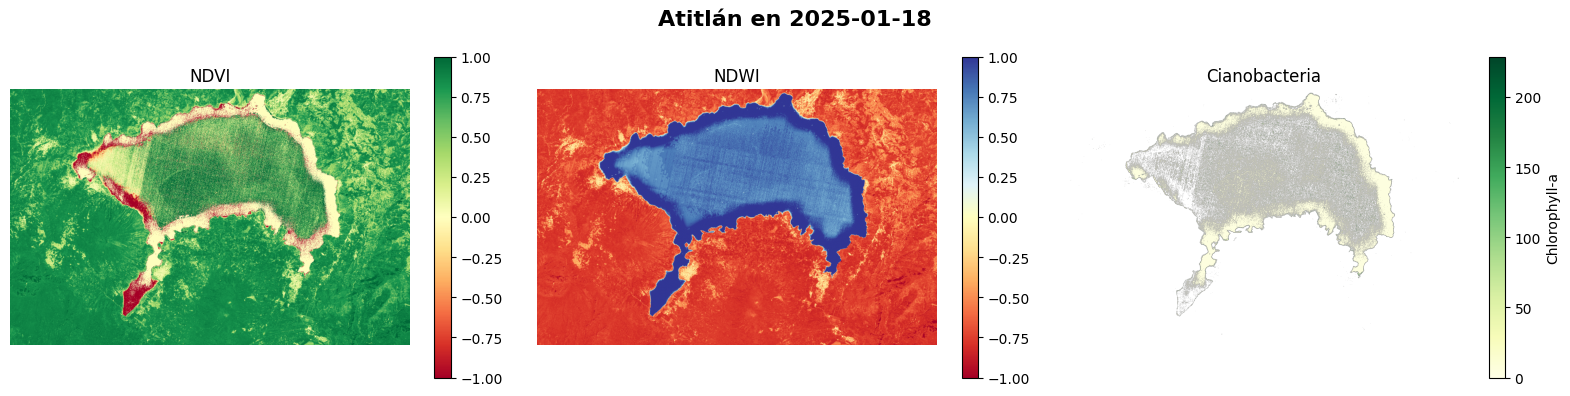

In [64]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

lago_viz = 'Atitlán'
fecha_viz = fechas[lago_viz][0]

ndvi = indices_calculados[lago_viz ][fecha_viz ]['NDVI']
ndwi = indices_calculados[lago_viz ][fecha_viz ]['NDWI']
cyano = indices_calculados[lago_viz ][fecha_viz ]['CYANO']

fig, axes = plt.subplots(1 , 3 , figsize = ( 16 , 4))

# ndvi
im1 = axes[0].imshow(ndvi, cmap = 'RdYlGn', vmin = -1, vmax =1)
axes[0].set_title('NDVI')
axes[0].axis('off' )
plt.colorbar(im1, ax= axes[0 ])

# ndwi
im2 = axes[1].imshow(ndwi, cmap ='RdYlBu', vmin= -1, vmax= 1 )
axes[1].set_title('NDWI')
axes[1].axis('off')

plt.colorbar(im2, ax= axes[1] )

# cianobacteria
im3 = axes[2].imshow(cyano, cmap='YlGn', vmin = 0, vmax=np.nanpercentile(cyano, 99 ) )
axes[2].set_title('Cianobacteria')
axes[2].axis('off')
plt.colorbar(im3, ax= axes[2], label = 'Chlorophyll-a')

plt.suptitle(f'{lago_viz} en {fecha_viz}', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.savefig('indices_punto3.png', dpi = 100, bbox_inches = 'tight')
plt.show()


In [65]:
B03 = bandas_procesadas["Atitlán"]["2025-01-18"]["B03" ]
B04 = bandas_procesadas["Atitlán"]["2025-01-18"]["B04" ]
B05 = bandas_procesadas["Atitlán"]["2025-01-18"]["B05" ]
B08 = bandas_procesadas["Atitlán"]["2025-01-18"]["B08" ]

ndwi_test = calcular_ndwi(B03 , B08)
cyano_raw = calcular_cyano_ndci(B04 , B05)

print("CYANO antes de máscara:")
print("Min:", np.nanmin(cyano_raw))
print("Max:", np.nanmax(cyano_raw))

mascara_agua = ndwi_test > 0

print("\nPíxeles considerados agua:")
print(mascara_agua.sum())

cyano_mask = np.where(mascara_agua, cyano_raw, np.nan)

print("\ndespués de máscara:")
print("válidos:", np.isfinite(cyano_mask).sum())
print("min:", np.nanmin(cyano_mask))
print("max:", np.nanmax(cyano_mask))

CYANO antes de máscara:
Min: -1017.929
Max: 673.2110000000001

Píxeles considerados agua:
858143

después de máscara:
válidos: 858143
min: -1017.929
max: 673.2110000000001


In [66]:
cyano = indices_calculados["Atitlán"]["2025-01-18"]["CYANO"]

print("rango real que estoy graficando:")
print(np.nanmin(cyano), np.nanmax(cyano))

rango real que estoy graficando:
0.00034785738149167855 498.9231000256016


# 4 análisis temporal

#### 4.1

In [67]:
resumen_temporal = []

for lago_nombre, fechas_dict in indices_calculados.items():
    for fecha, indices in fechas_dict.items( ):
        cyano = indices['CYANO']
        resumen_temporal.append({'Lago': lago_nombre,  'Fecha': fecha, 'Promedio_CYANO': np.nanmean(cyano)})

df_temporal = pd.DataFrame(resumen_temporal)

df_temporal['Fecha'] = pd.to_datetime(df_temporal['Fecha'])

df_temporal = df_temporal.sort_values( ['Lago', 'Fecha']).reset_index(drop=True)

print(df_temporal )

         Lago      Fecha  Promedio_CYANO
0   Amatitlán 2025-01-28       15.044943
1   Amatitlán 2025-04-15        8.002684
2   Amatitlán 2025-04-28       11.708208
3   Amatitlán 2025-11-24       10.739482
4   Amatitlán 2026-01-08       18.522571
5   Amatitlán 2026-02-02        6.105733
6   Amatitlán 2026-02-07        9.368457
7   Amatitlán 2026-03-29       13.374674
8   Amatitlán 2026-04-13       16.272248
9   Amatitlán 2026-04-28       16.538174
10  Amatitlán 2026-06-19       54.955857
11    Atitlán 2025-01-18       12.669683
12    Atitlán 2025-04-13        3.444488
13    Atitlán 2025-05-13        3.977853
14    Atitlán 2025-07-17        4.548163
15    Atitlán 2025-11-21       10.896335
16    Atitlán 2025-12-29        5.791325
17    Atitlán 2026-02-12        6.826409
18    Atitlán 2026-03-24        3.917712
19    Atitlán 2026-04-13        4.267569
20    Atitlán 2026-04-28        3.672624
21    Atitlán 2026-07-22        4.320894


## 4.2

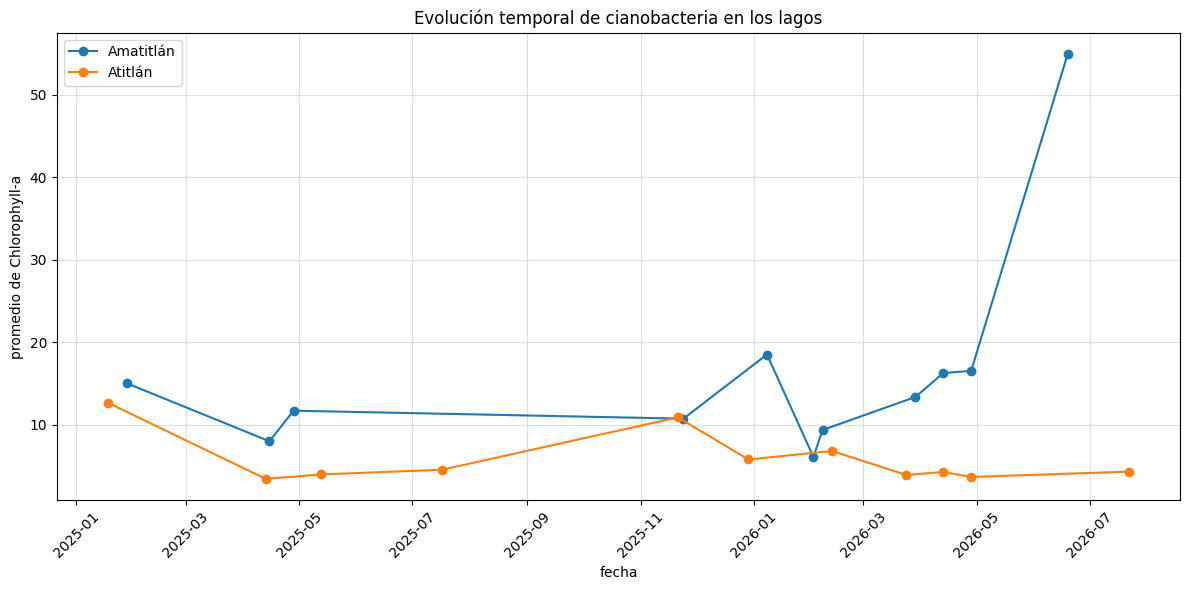

In [68]:
plt.figure(figsize=(12, 6))

for lago_nombre in df_temporal['Lago'].unique():

    datos_lago = df_temporal[ df_temporal['Lago'] == lago_nombre]

    plt.plot(  datos_lago['Fecha'],
        datos_lago['Promedio_CYANO'],
        marker='o', label=lago_nombre
    )

plt.title('Evolución temporal de cianobacteria en los lagos')

plt.xlabel('fecha')
plt.ylabel('promedio de Chlorophyll-a' )

plt.legend()
plt.grid(alpha = 0.4)
plt.xticks(rotation = 45)
plt.tight_layout()

plt.savefig('evolucion_temporal_cianobacteria.png',dpi = 150, bbox_inches='tight')

plt.show()

## 4.3

In [ ]:
print("fechas con mayor promedio de cianobacteria")

for lago_nombre in df_temporal[ 'Lago' ].unique():
    datos_lago = df_temporal[ df_temporal['Lago'] == lago_nombre ]
    fila_max = datos_lago.loc[  datos_lago['Promedio_CYANO'].idxmax() ]

    print(f"\n{lago_nombre}")
    print( f"fecha crítica: " f"{fila_max['Fecha'].strftime('%Y-%m-%d') }" )
    print( f"promedio máximo: " f"{fila_max['Promedio_CYANO']:.4f}" )

fechas con mayor promedio de cianobacteria

Amatitlán
fecha crítica: 2026-06-19
promedio máximo: 54.9559

Atitlán
fecha crítica: 2025-01-18
promedio máximo: 12.6697


In [72]:
for lago_nombre in df_temporal[ 'Lago' ].unique():
    datos_lago = df_temporal[ df_temporal['Lago'] == lago_nombre]
    top_3 = datos_lago.nlargest(3,'Promedio_CYANO')

    print(f"\n3 fechas con valores más altos de {lago_nombre}" )
    print(top_3[ ['Fecha', 'Promedio_CYANO'] ].to_string( index = False) )


3 fechas con valores más altos de Amatitlán
     Fecha  Promedio_CYANO
2026-06-19       54.955857
2026-01-08       18.522571
2026-04-28       16.538174

3 fechas con valores más altos de Atitlán
     Fecha  Promedio_CYANO
2025-01-18       12.669683
2025-11-21       10.896335
2026-02-12        6.826409
